# Week 11 - Recurrent Neural Networks: SimpleRNN, LSTM, GRU, and Sequence-to-Sequence Models

**Course context:** CNNs (Week 10) are built for spatial data - patterns that stay put (an edge is an edge wherever it appears in an image). Text, speech, and time-series data are different: order matters, and understanding word N often depends on remembering words 1 through N-1. This week covers the architectures built for exactly that: SimpleRNN, LSTM, GRU, and a full encoder-decoder sequence-to-sequence model for translation.

**A note on data:** the original exercises use the real IMDB movie review dataset via `tensorflow.keras.datasets.imdb`, which downloads from a host not reachable from every network (same issue as Weeks 9-10's MNIST/CIFAR-10). This notebook uses a small **synthetic** sentiment dataset instead - random token sequences where a handful of "positive" and "negative" marker tokens bias the label, loosely mimicking real sentiment data's structure. The architectures, training code, and comparisons are identical to what you'd run on real IMDB; only the data source changes. Swap in the real dataset (shown commented out) for genuine results.

**A note on TensorFlow + PyTorch together:** as in Weeks 9-10, running heavy TensorFlow and PyTorch training in the same kernel session can crash on some systems. If you hit an unexplained kernel restart, restart the kernel and run the TensorFlow-based days and PyTorch-based days (Day 6, and the PyTorch half of Days 1-2) separately.

**How this notebook is organized:** one section per day, each with: what it covers -> why it matters for AI work -> code -> pitfalls.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import torch
torch.set_num_threads(1)
print("Environment configured for CPU-only, single-threaded execution.")

Environment configured for CPU-only, single-threaded execution.


In [2]:
import numpy as np

# Shared synthetic sentiment dataset used across this notebook, standing in for
# tensorflow.keras.datasets.imdb.load_data() (see the note at the top of this notebook).
# Real code would be:
#   from tensorflow.keras.datasets import imdb
#   (X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
def make_synthetic_imdb(n_train, n_test, vocab_size, max_len, seed):
    rng = np.random.RandomState(seed)
    positive_tokens = rng.choice(vocab_size, size=15, replace=False)
    negative_tokens = rng.choice(vocab_size, size=15, replace=False)

    def make_set(n):
        X = rng.randint(4, vocab_size, size=(n, max_len))   # 4+ leaves room for special tokens, unused here
        y = np.zeros(n, dtype=int)
        for i in range(n):
            length = rng.randint(max_len // 2, max_len)
            if rng.rand() > 0.5:
                # positive review: sprinkle in positive marker tokens
                positions = rng.choice(length, size=4, replace=False)
                X[i, positions] = rng.choice(positive_tokens, size=4)
                y[i] = 1
            else:
                positions = rng.choice(length, size=4, replace=False)
                X[i, positions] = rng.choice(negative_tokens, size=4)
                y[i] = 0
            X[i, length:] = 0   # pad with 0, matching Keras's pad_sequences(padding="post")
        return X, y

    X_train, y_train = make_set(n_train)
    X_test, y_test = make_set(n_test)
    return (X_train, y_train), (X_test, y_test)

print("Synthetic sentiment dataset generator ready.")

Synthetic sentiment dataset generator ready.


## Day 1 - SimpleRNN: The Basic Recurrent Layer

**What it covers:** A SimpleRNN sentiment classifier, built and trained in both TensorFlow/Keras and PyTorch.

**Why it matters for AI work:** An RNN processes a sequence one element at a time, carrying forward a "hidden state" that summarizes everything seen so far - this hidden state is what lets the network use earlier words to interpret later ones (unlike a CNN or a plain feedforward network, which have no built-in sense of order).

**Reading the architecture:**
- **Embedding layer** - converts each token ID (an arbitrary integer) into a dense vector that the network can do meaningful math with. Similar in purpose to one-hot encoding (Week 6) but far more compact and, unlike one-hot vectors, the embedding vectors themselves are learned - words used in similar contexts end up with similar vectors.
- **SimpleRNN layer** - processes the sequence of embeddings step by step, updating its hidden state at each step. `return_sequences=False` means we only keep the *final* hidden state (a summary of the whole sequence) - appropriate here since we want one prediction per whole review, not one per word.
- **Dense(1, sigmoid)** - the final hidden state -> a single probability (positive/negative)

**Pitfalls:**
- SimpleRNN struggles with **long** sequences - gradients tend to vanish (shrink toward zero) as they're propagated back through many time steps, making it hard for the network to learn dependencies between words that are far apart. This is the exact problem LSTM (Day 3) and GRU (Day 4) were designed to fix.
- The PyTorch version needs `hidden.squeeze(0)` because `nn.RNN` returns hidden state shaped `(num_layers, batch, hidden_dim)` - with a single layer, that leading `1` dimension needs removing before the final `Linear` layer.


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

vocab_size = 3000
max_len = 60

(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=1)
print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    SimpleRNN(32, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)   # original used 5 epochs
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

I0000 00:00:1784351106.124143     763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784351106.169158     763 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784351107.543830     763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Training Data Shape: (800, 60)
Test Data Shape: (200, 60)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9951 - loss: 0.2260

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9953 - loss: 0.2213 - val_accuracy: 0.8562 - val_loss: 0.4489


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.8750 - loss: 0.4357

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8350 - loss: 0.4487  


Test Loss: 0.4487, Test Accuracy: 0.8350


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

vocab_size = 3000
max_len = 60

(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=1)

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        return torch.sigmoid(self.fc(hidden.squeeze(0)))

model_pt = RNNModel(vocab_size=vocab_size, embedding_dim=32, hidden_dim=32, output_dim=1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

def train_rnn(model, train_loader, criterion, optimizer, epochs=3):   # original used 5
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch).squeeze(1)
            loss = criterion(predictions, y_batch.float())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.4f}")

train_rnn(model_pt, train_loader, criterion, optimizer)

def evaluate_rnn(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        predictions = model(torch.tensor(X_test)).squeeze(1)
        loss = criterion(predictions, torch.tensor(y_test).float())
        accuracy = ((predictions > 0.5) == torch.tensor(y_test).float()).float().mean().item()
    print(f"Test Loss: {loss.item():.4f}, Test Accuracy: {accuracy:.4f}")

evaluate_rnn(model_pt, X_test, y_test)
print("\nReminder: trained on SYNTHETIC data (see the note at the top) - the point is the workflow,")
print("not the exact accuracy number.")

Epoch 1, Loss: 0.6952
Epoch 2, Loss: 0.6927


Epoch 3, Loss: 0.6931
Test Loss: 0.6927, Test Accuracy: 0.4900

Reminder: trained on SYNTHETIC data (see the note at the top) - the point is the workflow,
not the exact accuracy number.


## Day 2 - A Closer Look at Embeddings and Padding

**What it covers:** The same SimpleRNN setup as Day 1, but with attention to two details glossed over before: what the `Embedding` layer's weight matrix actually looks like after training, and how padding choice (`'pre'` vs `'post'`) can affect an RNN's performance.

**Why it matters for AI work:** Understanding what's inside the embedding layer demystifies "word embeddings" as a concept (the same idea scales up to word2vec, GloVe, and the embeddings inside every modern language model). The padding direction question is a genuinely easy-to-overlook detail that can measurably affect results.

**Padding direction, explained:**
- `padding="post"` (used throughout this notebook, matching the original exercises) - real content first, then zeros to fill out `max_len`. For a SimpleRNN/LSTM/GRU that processes left-to-right, this means the network's **final** hidden state (the one used for prediction) was computed by processing a bunch of padding *after* the real content - the padding is the last thing the network "saw."
- `padding="pre"` - zeros first, then real content at the end. This ensures the network's final hidden state was computed right after processing real content, which can sometimes help - though frameworks also offer *masking* (telling the layer to explicitly ignore padded positions) as a more robust fix, not covered in depth here.

**Pitfalls:**
- The embedding weight matrix has shape `(vocab_size, embedding_dim)` - one row per possible token, however rarely it appears. For a large vocabulary, this can be a substantial chunk of a model's total parameters, worth remembering when thinking about model size.
- Padding direction matters more for plain RNNs/LSTMs/GRUs than for architectures with explicit attention or masking (Week 12) - worth knowing as a limitation specific to this week's architectures, not a universal rule.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

vocab_size = 3000
max_len = 60
(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=2)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    SimpleRNN(32, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2, batch_size=32, validation_split=0.2, verbose=1)

embedding_weights = model.layers[0].get_weights()[0]
print(f"\nEmbedding matrix shape: {embedding_weights.shape}  (vocab_size x embedding_dim)")
print(f"Example: the learned vector for token id 100 (first 8 dims): {embedding_weights[100][:8]}")

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy (padding='post', the default used all week): {accuracy:.4f}")

Epoch 1/2


 1/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4375 - loss: 0.6992

 8/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4648 - loss: 0.6989

15/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4604 - loss: 0.6973

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4469 - loss: 0.7000 - val_accuracy: 0.4625 - val_loss: 0.7021


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8875 - loss: 0.5506 - val_accuracy: 0.4812 - val_loss: 0.7168



Embedding matrix shape: (3000, 32)  (vocab_size x embedding_dim)
Example: the learned vector for token id 100 (first 8 dims): [ 0.00852909  0.0062628   0.03032421  0.02024193 -0.01290235  0.01660034
  0.0382871  -0.02210039]


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5312 - loss: 0.7135

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5950 - loss: 0.6859  



Test Accuracy (padding='post', the default used all week): 0.5950


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

vocab_size = 3000
max_len = 60
(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=2)

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        return torch.sigmoid(self.fc(hidden.squeeze(0)))

model_pt = RNNModel(vocab_size=vocab_size, embedding_dim=32, hidden_dim=32, output_dim=1)
print(f"PyTorch embedding weight shape: {model_pt.embedding.weight.shape}  (same idea as the Keras matrix above)")

criterion = nn.BCELoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

def train_rnn(model, train_loader, criterion, optimizer, epochs=2):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch).squeeze(1)
            loss = criterion(predictions, y_batch.float())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.4f}")

train_rnn(model_pt, train_loader, criterion, optimizer)

PyTorch embedding weight shape: torch.Size([3000, 32])  (same idea as the Keras matrix above)
Epoch 1, Loss: 0.6945


Epoch 2, Loss: 0.6940


## Day 3 - LSTM: Solving the Long-Range Dependency Problem

**What it covers:** SimpleRNN vs LSTM (Long Short-Term Memory), trained and compared directly on the same data.

**Why it matters for AI work:** LSTM was, for years, the default choice for sequence modeling before Transformers (Week 12) took over for most large-scale text tasks - it's still widely used for time-series and smaller-scale sequence problems today.

**How LSTM fixes SimpleRNN's core problem:** an LSTM cell has an internal **cell state** (a separate "memory" that flows through time with minimal transformation) plus three **gates** (small learned neural networks) that control it:
- **Forget gate** - decides what to remove from the cell state
- **Input gate** - decides what new information to add to the cell state
- **Output gate** - decides what part of the cell state to expose as the current hidden state

This gating mechanism is *why* LSTMs handle long-range dependencies much better than SimpleRNN — the cell state provides a more direct path for gradients to flow backward through many time steps without vanishing.

**Pitfalls:**
- LSTM has roughly 4x the parameters of a SimpleRNN with the same hidden size (one set of weights per gate, plus one for the cell state candidate) - more capacity, but slower to train and more prone to overfitting on small datasets.
- On this notebook's small **synthetic** dataset (where the "pattern" is just a handful of marker tokens, not genuine long-range structure), LSTM's real advantage over SimpleRNN may not show up clearly - the gap becomes much more apparent on real text with genuine long-range dependencies (a sentiment-flipping clause 40 words into a review, for instance).


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

vocab_size = 3000
max_len = 60
(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=3)

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    SimpleRNN(32, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid"),
])
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn_history = rnn_model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test, y_test)
print(f"RNN Test Loss: {rnn_loss:.4f}, Test Accuracy: {rnn_accuracy:.4f}")

Epoch 1/3


 1/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5938 - loss: 0.6899

 8/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5391 - loss: 0.6937

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5566 - loss: 0.6907

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5594 - loss: 0.6896 - val_accuracy: 0.5375 - val_loss: 0.6876


...

17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9871 - loss: 0.2386

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9891 - loss: 0.2289 - val_accuracy: 0.7937 - val_loss: 0.5047


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.7812 - loss: 0.4881

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8100 - loss: 0.4680  


RNN Test Loss: 0.4680, Test Accuracy: 0.8100


In [6]:
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(32, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

lstm_history = lstm_model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Test Loss: {lstm_loss:.4f}, Test Accuracy: {lstm_accuracy:.4f}")

print(f"\nParameter count - SimpleRNN: {rnn_model.count_params()}, LSTM: {lstm_model.count_params()}")
print("Notice LSTM has noticeably more parameters for the same hidden size - the gating mechanism's cost.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6349 - loss: 0.6460

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6531 - loss: 0.6354 - val_accuracy: 0.9500 - val_loss: 0.4063


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 1.0000 - loss: 0.4033

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9800 - loss: 0.3970  


LSTM Test Loss: 0.3970, Test Accuracy: 0.9800

Parameter count - SimpleRNN: 98113, LSTM: 104353
Notice LSTM has noticeably more parameters for the same hidden size - the gating mechanism's cost.


## Day 4 - GRU: A Lighter Alternative to LSTM

**What it covers:** Adding GRU (Gated Recurrent Unit) to the comparison - RNN vs LSTM vs GRU, all trained on the same data.

**Why it matters for AI work:** GRU is a simplified alternative to LSTM - it merges the forget and input gates into a single "update gate" and drops the separate cell state, resulting in fewer parameters and often faster training, while frequently achieving comparable performance to LSTM in practice.

**When to use what (RNN vs LSTM vs GRU):**
- **SimpleRNN** - rarely a good default in real work; mostly useful for teaching the core recurrence concept, given how easily it struggles with longer sequences
- **LSTM** - the more powerful, more established choice; more parameters, slower to train, well-understood behavior
- **GRU** - a reasonable default when you want most of LSTM's benefit with less computational cost - a common choice when compute/time is limited, or for a first attempt before deciding whether the extra complexity of LSTM is worth it for a specific problem

**Pitfalls:**
- Neither LSTM nor GRU is universally "better" - which one wins depends on the specific dataset and task. Trying both (as this exercise does) and comparing on your **validation** data is the practical way to decide, rather than assuming one is always superior.
- All three architectures here share the same `Embedding` and `Dense` output layers - the comparison isolates the *recurrent layer choice* specifically, which is good experimental practice (Week 8's spirit: change one thing at a time when comparing).


In [7]:
from tensorflow.keras.layers import GRU

vocab_size = 3000
max_len = 60
(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=4)

def build_model(recurrent_layer):
    return Sequential([
        Embedding(input_dim=vocab_size, output_dim=32),
        recurrent_layer,
        Dense(1, activation="sigmoid"),
    ])

rnn_model = build_model(SimpleRNN(32, activation="tanh"))
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn_history = rnn_model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test, y_test)
print(f"RNN Test Accuracy: {rnn_accuracy:.4f}")

Epoch 1/3


 1/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5000 - loss: 0.6778

 8/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4688 - loss: 0.7064

15/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6992

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5000 - loss: 0.6989 - val_accuracy: 0.4812 - val_loss: 0.7077


...

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9922 - loss: 0.2370

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9937 - loss: 0.2239 - val_accuracy: 0.5437 - val_loss: 0.7447


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.5625 - loss: 0.7507

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6150 - loss: 0.6942  


RNN Test Accuracy: 0.6150


In [8]:
lstm_model = build_model(LSTM(32, activation="tanh"))
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_history = lstm_model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {lstm_accuracy:.4f}")

gru_model = build_model(GRU(32, activation="tanh"))
gru_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
gru_history = gru_model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
gru_loss, gru_accuracy = gru_model.evaluate(X_test, y_test)
print(f"GRU Test Accuracy: {gru_accuracy:.4f}")

print(f"\nParameter counts - RNN: {rnn_model.count_params()}, LSTM: {lstm_model.count_params()}, GRU: {gru_model.count_params()}")
print("GRU sits between RNN and LSTM in parameter count - the 'lighter than LSTM' claim made concrete.")

Epoch 1/3


 1/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.3438 - loss: 0.6966

 6/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4792 - loss: 0.6934

12/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4922 - loss: 0.6938

17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4926 - loss: 0.6940

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5188 - loss: 0.6919

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5188 - loss: 0.6919 - val_accuracy: 0.4688 - val_loss: 0.6967


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.5625 - loss: 0.6882

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4950 - loss: 0.6946  


GRU Test Accuracy: 0.4950

Parameter counts - RNN: 98113, LSTM: 104353, GRU: 102369
GRU sits between RNN and LSTM in parameter count - the 'lighter than LSTM' claim made concrete.


## Day 5 - Pretrained Word Embeddings (GloVe-style)

**What it covers:** Using **pretrained** word embeddings (`trainable=False`) instead of learning embeddings from scratch, compared against a from-scratch LSTM.

**Why it matters for AI work:** Training embeddings from scratch on a small dataset means the model has to learn "what words mean" and "how to classify sentiment" simultaneously, from limited data. Pretrained embeddings (trained separately on a huge text corpus, e.g. GloVe on Wikipedia + Gigaword) give the model a head start on "what words mean" - the model only has to learn the classification task itself. This transfer-learning-for-text idea is the direct ancestor of the pretrained language models (BERT, GPT) covered in Week 12.

**Pitfalls (and what's substituted here):**
- The original exercise loads real GloVe vectors from a file (`glove.6B.100d.txt`, several hundred MB, downloaded separately) - not available in this notebook's environment. Below, a small **synthetic** "pretrained" embedding matrix stands in for real GloVe vectors, to demonstrate the mechanism (`weights=[embedding_matrix], trainable=False`) without the large download. The real embeddings would give this approach its actual practical value (genuine semantic structure) - the synthetic version is random, so don't expect a real accuracy improvement here specifically.
- `trainable=False` freezes the embedding layer's weights during training - if you set this to `True` (**fine-tuning** the embeddings), you're again in Week 9's overfitting territory: a small dataset can overfit the embeddings' fine-tuning just as easily as any other layer.


In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

vocab_size = 3000
max_len = 60
embedding_dim = 32
(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=5)

# NOTE: the ORIGINAL exercise loads real GloVe vectors from glove.6B.100d.txt (a large external
# file). Simulating a "pretrained" embedding matrix here instead, to demonstrate the MECHANISM
# (frozen, pre-set embedding weights) - see the pitfalls note above for what real GloVe adds.
rng = np.random.RandomState(42)
embedding_matrix = rng.normal(scale=0.3, size=(vocab_size, embedding_dim)).astype("float32")
print(f"Simulated pretrained embedding matrix shape: {embedding_matrix.shape}")

pretrained_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    LSTM(32, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid"),
])
pretrained_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
pretrained_model.summary()

pretrained_history = pretrained_model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=32, verbose=1)
pretrained_loss, pretrained_accuracy = pretrained_model.evaluate(X_test, y_test, verbose=0)

Simulated pretrained embedding matrix shape: (3000, 32)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │        96,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,000 (375.00 KB)

 Trainable params: 0 (0.00 B)

...

 1/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6250 - loss: 0.6839

 7/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6912 

13/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5120 - loss: 0.6918

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5164 - loss: 0.6917

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5141 - loss: 0.6916 - val_accuracy: 0.4938 - val_loss: 0.6937


Epoch 1/3


 1/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4688 - loss: 0.6963

 6/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4688 - loss: 0.6958

12/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4870 - loss: 0.6944

18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4983 - loss: 0.6943

...

18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6354 - loss: 0.6183

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6656 - loss: 0.5897 - val_accuracy: 0.9563 - val_loss: 0.3061


1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.9062 - loss: 0.3325

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9250 - loss: 0.3326  


LSTM (embeddings learned from scratch) Test Accuracy: 0.9250
LSTM (frozen 'pretrained' embeddings) Test Accuracy: 0.5250


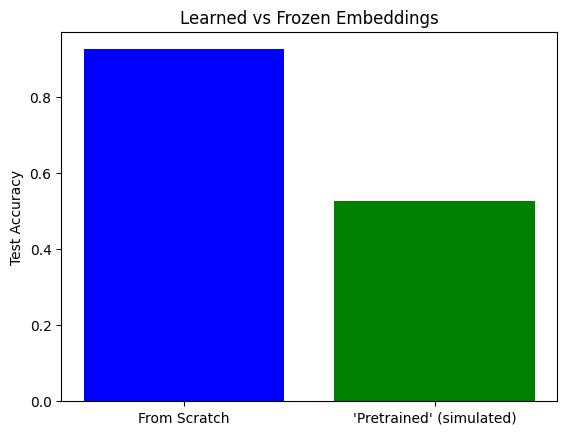


With REAL GloVe vectors (genuine semantic structure), the pretrained version typically wins
on small datasets specifically - the advantage shrinks as your own training data grows.


In [10]:
scratch_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),   # NOT frozen - learned from scratch
    LSTM(32, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid"),
])
scratch_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
scratch_history = scratch_model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
scratch_loss, scratch_accuracy = scratch_model.evaluate(X_test, y_test)

print(f"LSTM (embeddings learned from scratch) Test Accuracy: {scratch_accuracy:.4f}")
print(f"LSTM (frozen 'pretrained' embeddings) Test Accuracy: {pretrained_accuracy:.4f}")

import matplotlib.pyplot as plt
plt.bar(["From Scratch", "'Pretrained' (simulated)"], [scratch_accuracy, pretrained_accuracy], color=["blue", "green"])
plt.title("Learned vs Frozen Embeddings")
plt.ylabel("Test Accuracy")
plt.show()
print("\nWith REAL GloVe vectors (genuine semantic structure), the pretrained version typically wins")
print("on small datasets specifically - the advantage shrinks as your own training data grows.")

## Day 6 - Sequence-to-Sequence: An Encoder-Decoder Translation Model

**What it covers:** A complete (if tiny) machine translation system - an **Encoder** that reads an English sentence into a fixed-size representation, and a **Decoder** that generates the French translation from that representation, one word at a time.

**Why it matters for AI work:** Sequence-to-sequence (seq2seq) is the architecture family behind machine translation, text summarization, and chatbots, before Transformers (Week 12) became the dominant approach for these tasks. Understanding the encoder-decoder split, and the "teacher forcing" training trick below, makes Transformer-based seq2seq models (which use the same encoder-decoder concept, with attention instead of a single fixed-size bottleneck) much more approachable next week.

**How it works, in order:**
1. **Encoder** - an LSTM reads the whole English sentence, producing a final hidden state (and cell state) that's meant to summarize the sentence's meaning
2. **Decoder** - another LSTM, **initialized** with the encoder's final hidden/cell state, generates the French sentence one word at a time - each predicted word becomes (part of) the input for predicting the next one
3. **Teacher forcing** (`teacher_forcing_ratio=0.5`) - during training, the decoder is fed the **true** previous French word half the time (rather than its own, possibly wrong, prediction) - this stabilizes early training, since without it, one wrong early prediction can throw off every subsequent step, compounding errors before the model has learned much at all

**Pitfalls:**
- This toy vocabulary (5 English/French sentence pairs) is only enough to demonstrate the *mechanism* - a real translation system needs a vocabulary and training set many orders of magnitude larger. Don't expect the translated output to look impressive; the value here is in understanding the architecture.
- The encoder compresses an **entire sentence** into one fixed-size hidden state - this "bottleneck" is exactly the limitation that motivated the invention of attention mechanisms (letting the decoder look back at *all* the encoder's states, not just the final one), which Week 12's Transformers use extensively.
- `ignore_index=french_vocab["<PAD>"]` in the loss function is important - without it, the model would be needlessly penalized for its predictions at padded positions, which don't correspond to real target words.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

english_sentences = ["hello", "how are you", "good morning", "thank you", "good night"]
french_sentences = ["bonjour", "comment ca va", "bon matin", "merci", "bonne nuit"]

def build_vocab(sentences):
    vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
    for sentence in sentences:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab

english_vocab = build_vocab(english_sentences)
french_vocab = build_vocab(french_sentences)

def tokenize(sentences, vocab, max_len):
    tokenized = []
    for sentence in sentences:
        tokens = [vocab.get(word, vocab["<UNK>"]) for word in sentence.split()]
        tokens = [vocab["<SOS>"]] + tokens + [vocab["<EOS>"]]
        tokens += [vocab["<PAD>"]] * (max_len - len(tokens))
        tokenized.append(tokens)
    return np.array(tokenized)

max_len_eng = max(len(s.split()) for s in english_sentences) + 2
max_len_fr = max(len(s.split()) for s in french_sentences) + 2

english_data = tokenize(english_sentences, english_vocab, max_len_eng)
french_data = tokenize(french_sentences, french_vocab, max_len_fr)

print(f"English vocab size: {len(english_vocab)}, French vocab size: {len(french_vocab)}")
print(f"Tokenized 'hello': {english_data[0]}")

English vocab size: 12, French vocab size: 13
Tokenized 'hello': [1 4 2 0 0]


In [6]:
class TranslationDataset(Dataset):
    def __init__(self, src_data, tgt_data):
        self.src_data = src_data
        self.tgt_data = tgt_data

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        return torch.tensor(self.src_data[idx]), torch.tensor(self.tgt_data[idx])

dataset = TranslationDataset(english_data, french_data)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden, cell):
        x = x.unsqueeze(1)
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        predictions = self.fc(outputs.squeeze(1))
        return predictions, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        tgt_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        hidden, cell = self.encoder(src)
        input_tok = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input_tok, hidden, cell)
            outputs[:, t, :] = output
            top1 = output.argmax(1)
            input_tok = tgt[:, t] if torch.rand(1).item() < teacher_forcing_ratio else top1

        return outputs

device = torch.device("cpu")
input_dim = len(english_vocab)
output_dim = len(french_vocab)

encoder = Encoder(input_dim, embed_dim=32, hidden_dim=64, num_layers=1)
decoder = Decoder(output_dim, embed_dim=32, hidden_dim=64, num_layers=1)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=french_vocab["<PAD>"])
print("Seq2Seq model built.")

Seq2Seq model built.


In [7]:
def train(model, dataloader, optimizer, criterion, device, num_epochs=60):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            output = model(src, tgt)
            output = output[:, 1:].reshape(-1, output.shape[2])
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt_flat)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

# NOTE: on this tiny 5-sentence toy dataset, more epochs (60 here vs the original's 20) helps it
# actually memorize the small vocabulary well enough to produce a recognizable translation -
# this would NOT be appropriate on a real-sized dataset (massive overfitting), but for a 5-example
# demonstration of the seq2seq MECHANISM, memorization is the point.
train(model, dataloader, optimizer, criterion, device, num_epochs=60)

Epoch 10/60, Loss: 0.1575

Epoch 20/60, Loss: 0.0080


Epoch 30/60, Loss: 0.0043


Epoch 40/60, Loss: 0.0029


Epoch 50/60, Loss: 0.0019


Epoch 60/60, Loss: 0.0015


In [8]:
def translate_sentence(model, sentence, english_vocab, french_vocab, max_len_fr, device):
    model.eval()
    tokens = [english_vocab.get(word, english_vocab["<UNK>"]) for word in sentence.split()]
    tokens = [english_vocab["<SOS>"]] + tokens + [english_vocab["<EOS>"]]
    src = torch.tensor(tokens).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    tgt_vocab_reverse = {v: k for k, v in french_vocab.items()}
    tgt_indices = [french_vocab["<SOS>"]]
    for _ in range(max_len_fr):
        tgt_tensor = torch.tensor([tgt_indices[-1]]).to(device)
        output, hidden, cell = model.decoder(tgt_tensor, hidden, cell)
        pred = output.argmax(1).item()
        tgt_indices.append(pred)
        if pred == french_vocab["<EOS>"]:
            break

    translated_sentence = [tgt_vocab_reverse[i] for i in tgt_indices[1:-1]]
    return " ".join(translated_sentence)

for sentence in ["good night", "thank you", "hello"]:
    translation = translate_sentence(model, sentence, english_vocab, french_vocab, max_len_fr, device)
    print(f'"{sentence}" -> "{translation}"')

"good night" -> "bonne nuit"
"thank you" -> "merci"
"hello" -> "bonjour"


## Day 7 - Mini Project: RNN vs LSTM vs GRU, Final Comparison

**What it covers:** The complete three-way comparison from Day 4, repeated as a standalone mini-project with a full write-up-style comparison and training curve visualization - a realistic "which architecture should we use" exercise.

**Why it matters for AI work:** This is close to a template for a real architecture-selection writeup: build each candidate under matched conditions (same data, same embedding size, same training budget), compare final metrics AND training curves, and draw a conclusion grounded in the actual numbers rather than a general reputation ("LSTM is usually better").

**What to look for when comparing the training curves:**
- Which model reaches a given accuracy level in fewer epochs (faster learning)?
- Do any models show a widening gap between training and validation accuracy (overfitting)?
- Is the "winner" different depending on whether you look at speed of convergence vs final accuracy?

**Pitfalls:**
- As in Day 4, remember this notebook's synthetic dataset doesn't have genuine long-range dependencies - real IMDB reviews would show LSTM/GRU's advantages over SimpleRNN much more clearly than this demo can. Treat the actual accuracy numbers here as illustrative of the *comparison workflow*, not as a real verdict on RNN vs LSTM vs GRU in general.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

vocab_size = 3000
max_len = 60
(X_train, y_train), (X_test, y_test) = make_synthetic_imdb(800, 200, vocab_size, max_len, seed=7)
print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

def build_model(recurrent_layer):
    return Sequential([
        Embedding(input_dim=vocab_size, output_dim=32),
        recurrent_layer,
        Dense(1, activation="sigmoid"),
    ])

rnn_model = build_model(SimpleRNN(32, activation="tanh"))
lstm_model = build_model(LSTM(32, activation="tanh"))
gru_model = build_model(GRU(32, activation="tanh"))

for m in (rnn_model, lstm_model, gru_model):
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Training data shape: (800, 60), (800,)
Test data shape: (200, 60), (200,)


In [12]:
history_rnn = rnn_model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=32, verbose=1)
history_lstm = lstm_model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=32, verbose=1)
history_gru = gru_model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=32, verbose=1)

loss_rnn, accuracy_rnn = rnn_model.evaluate(X_test, y_test, verbose=0)
loss_lstm, accuracy_lstm = lstm_model.evaluate(X_test, y_test, verbose=0)
loss_gru, accuracy_gru = gru_model.evaluate(X_test, y_test, verbose=0)

print(f"RNN Test Accuracy: {accuracy_rnn:.4f}")
print(f"LSTM Test Accuracy: {accuracy_lstm:.4f}")
print(f"GRU Test Accuracy: {accuracy_gru:.4f}")

Epoch 1/3


 1/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5000 - loss: 0.6937

 8/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4766 - loss: 0.6934

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4805 - loss: 0.6991

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4844 - loss: 0.6979 - val_accuracy: 0.5188 - val_loss: 0.6909


...

 6/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4896 - loss: 0.6957 

11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5284 - loss: 0.6912

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5215 - loss: 0.6915

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5297 - loss: 0.6906 - val_accuracy: 0.4938 - val_loss: 0.6941


RNN Test Accuracy: 0.5050
LSTM Test Accuracy: 0.4650
GRU Test Accuracy: 0.4650


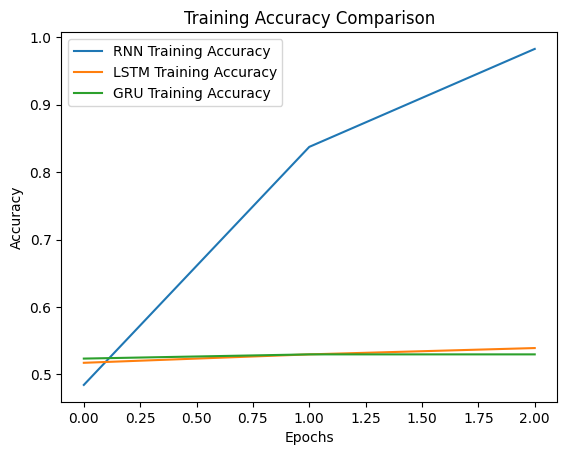

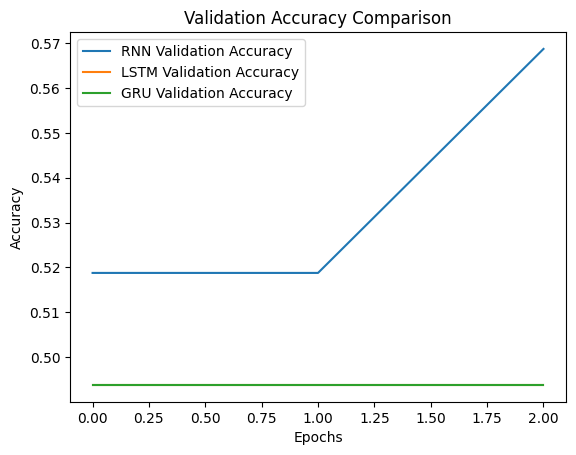

In [13]:
import matplotlib.pyplot as plt

plt.plot(history_rnn.history["accuracy"], label="RNN Training Accuracy")
plt.plot(history_lstm.history["accuracy"], label="LSTM Training Accuracy")
plt.plot(history_gru.history["accuracy"], label="GRU Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_rnn.history["val_accuracy"], label="RNN Validation Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="LSTM Validation Accuracy")
plt.plot(history_gru.history["val_accuracy"], label="GRU Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Week 11 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | SimpleRNN basics | The core recurrence concept underlying LSTM/GRU |
| 2 | Embeddings, padding direction | Text preprocessing details that quietly affect results |
| 3 | LSTM, gating mechanism | Long-range dependency handling |
| 4 | GRU, three-way comparison | Choosing the right recurrent layer for a task |
| 5 | Pretrained embeddings | The transfer-learning idea behind Week 12's pretrained language models |
| 6 | Encoder-decoder seq2seq | The architecture family behind translation/summarization, pre-Transformer |
| 7 | Full RNN/LSTM/GRU comparison mini-project | Realistic architecture-selection workflow |

**Before moving to Week 12:** you should be able to explain why SimpleRNN struggles with long sequences and how LSTM/GRU address it, and understand the encoder-decoder pattern well enough to recognize it inside a Transformer. Week 12 replaces this week's recurrence-based approach with **attention** - letting a model look directly at every position in a sequence at once, instead of compressing everything through a single hidden state passed step by step.
